# Homework 5

:::{warning} Code Source
All snippets directly migrated from [](https://brian-rose.github.io/ClimateLaboratoryBook/courseware/rce/)
:::

### 1.3 Effect of Albedo And $\mathrm{CO_2}$ On Temperature Distribution In RCM

:::{attention} Problem Statement 
It is possible to vary the albedo and the CO2 content in the RCE model (hint: look into absorber_vmr and albedo). Vary the albedo between 0 and 1 and the CO2 content between 0.125 and 8x of the default value. Visualize the temperature profiles. Also, plot the sensitivity of Tsfc to different combinations of the two variables.
:::

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import climlab 
from metpy.plots import SkewT

Get some data:

In [4]:

###########################################
########## CESM : Water Vapor #############
###########################################
cesm_data_path = "http://thredds.atmos.albany.edu:8080/thredds/dodsC/CESMA/"
atm_control = xr.open_dataset(cesm_data_path + "cpl_1850_f19/concatenated/cpl_1850_f19.cam.h0.nc")
weight_factor = atm_control.gw / atm_control.gw.mean(dim='lat')
Qglobal = (atm_control.Q * weight_factor).mean(dim=('lat','lon','time'))

###########################################
########## NCEP : Temperature #############
###########################################
ncep_url = "http://www.esrl.noaa.gov/psd/thredds/dodsC/Datasets/ncep.reanalysis.derived/"
time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
ncep_air = xr.open_dataset( ncep_url + "pressure/air.mon.1981-2010.ltm.nc", decode_times=time_coder)
#  Get global temperature
coslat = np.cos(np.deg2rad(ncep_air.lat))
weight = coslat / coslat.mean(dim='lat')
Tglobal = (ncep_air.air * weight).mean(dim=('lat','lon','time'))

Some helper functions to plot Skew-T plots:

In [64]:
#  Resuable function to plot the temperature data on a Skew-T chart
def make_skewT():
    fig = plt.figure(figsize=(9, 9))
    skew = SkewT(fig, rotation=30)
    skew.plot(Tglobal.level, Tglobal, color='black', linestyle='-', linewidth=2, label='Observations')
    skew.ax.set_ylim(1050, 10)
    skew.ax.set_xlim(-90, 45)
    # Add the relevant special lines
    skew.plot_dry_adiabats(linewidth=0.5)
    skew.plot_moist_adiabats(linewidth=0.5)
    #skew.plot_mixing_lines()
    skew.ax.legend()
    skew.ax.set_xlabel('Temperature (degC)', fontsize=14)
    skew.ax.set_ylabel('Pressure (hPa)', fontsize=14)
    return skew

#  and a function to add extra profiles to this chart
def add_profile(skew, model, linestyle='-', color=None):
    T_atm = skew.plot(model.lev, model.Tatm - climlab.constants.tempCtoK,
             label=model.name, linewidth=2, color=color)[0]
    T_surf = skew.plot(1000, model.Ts - climlab.constants.tempCtoK, 'o', 
              markersize=8, color=color)[0]
    skew.ax.legend()
    return (T_atm, T_surf)

Assemble the radiative-convective model

In [62]:
def create_rcm(co2_ratio, albedo, model_name):
    #  Make a model on same vertical domain as the GCM
    mystate = climlab.column_state(lev=Qglobal.lev, water_depth=2.5)
    #  Build the radiation model -- just like we already did
    rad = climlab.radiation.RRTMG(name='Radiation',
                                state=mystate, 
                                specific_humidity=Qglobal.values,
                                timestep = climlab.constants.seconds_per_day,
                                albedo = albedo,  # adjust albedo here
                                )
    #adjust CO2 here
    rad.absorber_vmr['CO2'] *= co2_ratio
    #  Now create the convection model
    conv = climlab.convection.ConvectiveAdjustment(name='Convection',
                                                state=mystate,
                                                adj_lapse_rate=6.5, # lapse rate
                                                timestep=rad.timestep,  # same timestep!
                                                )
    #  Here is where we build the model by coupling together the two components
    rcm = climlab.couple([rad, conv], name=model_name)

    return rcm

Define a grid of configurations:

In [74]:
co2_ratios = [0.125, 1.5, 8.0]
albedos = [0.0, 0.25, 0.75]

rcms = []
for co2_ratio in co2_ratios:
    for albedo in albedos:
        rcms.append(create_rcm(co2_ratio, albedo, model_name=f"CO2 at {co2_ratio}, albedo at {albedo}"))

Write a helper to generate distinct colors

In [70]:
import colorsys
def get_visually_distinct_colors(n):
    """
    Generates a list of n visually distinct colors in RGB tuple format (0-255).
    """
    colors = []
    # Iterate through the hue spectrum
    for i in range(n):
        hue = i / n
        saturation = 0.8 # Maintain high saturation
        value = 0.9 # Maintain good brightness
        
        # Convert HSV to RGB (normalized to 0-1)
        rgb_normalized = colorsys.hsv_to_rgb(hue, saturation, value)
        
        colors.append(rgb_normalized)
    return colors

Copy and modify the code for animation over from the website:

In [85]:
#  Some imports needed to make and display animations
from IPython.display import HTML
from matplotlib import animation

def get_tendencies(model):
    '''Pack all the subprocess tendencies into xarray.Datasets
    and convert to units of K / day'''
    tendencies_atm = xr.Dataset()
    tendencies_sfc = xr.Dataset()
    for name, proc, top_proc in climlab.utils.walk.walk_processes(model, topname='Total', topdown=False):
        tendencies_atm[name] = proc.tendencies['Tatm'].to_xarray()
        tendencies_sfc[name] = proc.tendencies['Ts'].to_xarray()
    for tend in [tendencies_atm, tendencies_sfc]:
        #  convert to K / day
        tend *= climlab.constants.seconds_per_day
    return tendencies_atm, tendencies_sfc

def initial_figure(models):
    fig = plt.figure(figsize=(14,6))
    lines_dict = {}
    
    skew = SkewT(fig, subplot=(1,2,1), rotation=30)
    #  plot the observations
    skew.plot(Tglobal.level, Tglobal, color='black', linestyle='-', linewidth=2, label='Observations')    

    skew.ax.legend()
    skew.ax.set_ylim(1050, 10)
    skew.ax.set_xlim(-60, 75)
    # Add the relevant special lines
    skew.plot_dry_adiabats(linewidth=0.5)
    skew.plot_moist_adiabats(linewidth=0.5)
    skew.ax.set_xlabel('Temperature (°C)', fontsize=14)
    skew.ax.set_ylabel('Pressure (hPa)', fontsize=14)
    
    colors = get_visually_distinct_colors(len(rcms))
    
    for i in range(len(models)):
        model = models[i]
        #  Start from isothermal state
        model.state.Tatm[:] = model.state.Ts
        #  Call the diagnostics once for initial plotting
        model.compute_diagnostics()
        line_tuple = add_profile(skew, model=model, color=colors[i])
        lines_dict[model.name] = line_tuple
        
    lines_dict['days_elapsed'] = (skew.ax.text(-100, 50, 'Day {}'.format(int(model.time['days_elapsed'])), fontsize=12)) 
    return fig, lines_dict

def animate(day, models, lines_dict):
    for model in models:
        lines_dict[model.name][0].set_xdata(np.array(model.Tatm)-climlab.constants.tempCtoK)
        lines_dict[model.name][1].set_xdata(np.array(model.Ts)-climlab.constants.tempCtoK)
        if day != 0:
            model.step_forward()
    lines_dict['days_elapsed'].set_text('Day {}'.format(int(model.time['days_elapsed'])))
   
    

Now plot the initial state(isothermal):

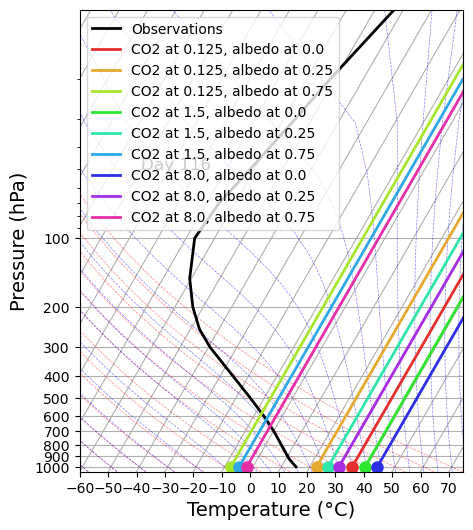

In [86]:
#  Plot initial data
fig, lines_dict = initial_figure(rcms)


Animate:

In [87]:
ani = animation.FuncAnimation(fig, animate, 100, fargs=(rcms, lines_dict))
HTML(ani.to_html5_video())